---
title: "Fourier Series and Transforms"
---

In [1]:
from scipy.fft import fft, ifft, fftshift, fft2, ifft2
from scipy.signal import stft
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import pywt
from scipy.io.wavfile import read as wave_read
%matplotlib inline 

In [2]:
# We need a tool that converts images into grayscale (i.e. all pixel values in [0, 1])
def gray_scale_convert(image):
    rescaled_image = np.zeros((image.shape[0], image.shape[1]))
    rescaled_image[:, :] = image
    rescaled_image -= np.min(rescaled_image)
    rescaled_image /= np.max(rescaled_image)
    return rescaled_image

# Noisy Signals

Just to get a sense of the power of the FFT, we look at the signal 

$$
s(t) = \cos(2t) + \sin(3t) + \epsilon(t),  \epsilon(t) \sim \mathcal{N}(0, 1).
$$

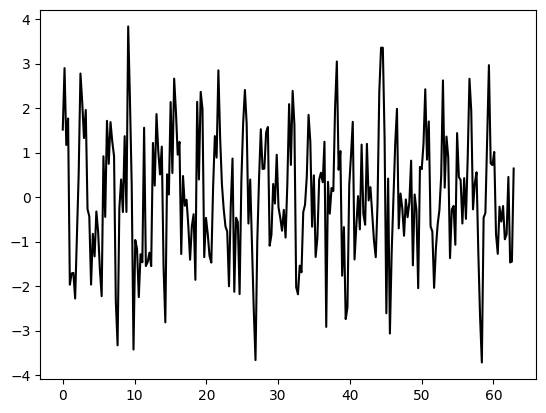

In [3]:
Npts = int(2**8)
times = np.linspace(0., 20.*np.pi, Npts)
rvals = np.random.randn(Npts)
sfun = lambda t: np.cos(2.*t) + np.sin(3.*t)
svals = sfun(times) + rvals

plt.plot(times, svals, 'k')
#plt.plot(times, sfun(times), 'r--')

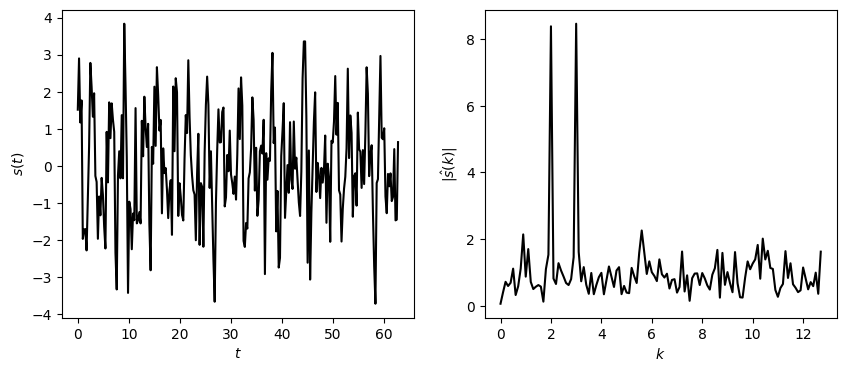

In [4]:
sfreq = fft(svals)
sfreq_plot = np.abs(fftshift(sfreq[:]))/np.sqrt(Npts)
kvals = np.arange(0, int(Npts/2)) * (2.*np.pi)/(20.*np.pi)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].plot(times, svals, 'k')
ax[0].set_xlabel(r"$t$")
ax[0].set_ylabel(r"$s(t)$")

ax[1].plot(kvals, sfreq_plot[int(Npts/2):], 'k')
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$|\hat{s}(k)|$");


So now, if we want to denoise, we use the same kind of threshholding to maximum arguments we used for the SVD.  This looks like:

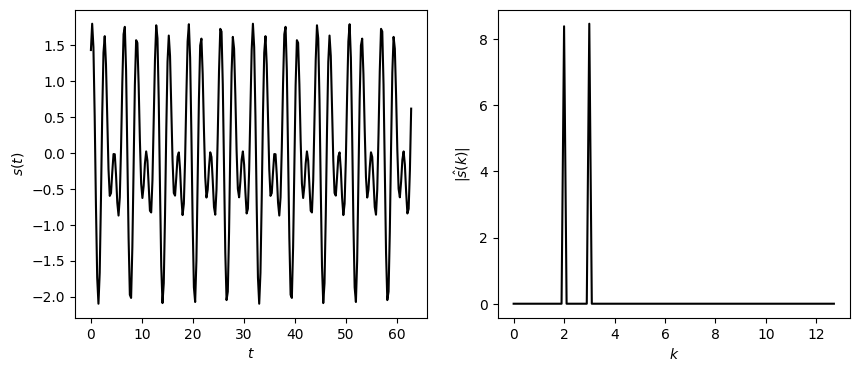

In [5]:
sfmax = np.max(np.abs(sfreq))
indskp = np.ma.log2(np.abs(sfreq)/sfmax) >= -1
sfilter = np.zeros(sfreq.size, dtype=np.complex128)
sfilter[indskp] = sfreq[indskp]
sfilter_plot = fftshift(np.abs(sfilter))/np.sqrt(Npts)
sdenoised = np.real(ifft(sfilter))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].plot(times, sdenoised, 'k')
#ax[0].plot(times, sfun(times), 'r--')
ax[0].set_xlabel(r"$t$")
ax[0].set_ylabel(r"$s(t)$")

ax[1].plot(kvals, sfilter_plot[int(Npts/2):], 'k')
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$|\hat{s}(k)|$");

## FFT Theory

For $f(t+T)=f(t)$ with $f(t) \in L_{2}([0, T])$, again, we define the Fourier coefficient $\hat{f}_{n}$ for $n\in \mathbb{Z}$ as 

$$
\hat{f}_{n} = \left<f,\hat{e}_{n}\right> = \frac{1}{\sqrt{T}}\int_{0}^{T}f(t) e^{-2\pi i n t/T} dt.  
$$

With a modicum of theory, we can in turn write

$$
f(t) = \sum_{n=-\infty}^{\infty}\hat{f}_{n}\hat{e}_{n}(t), ~\hat{e}_{n}(t) = \frac{1}{\sqrt{T}}e^{-2\pi i n t/T}.
$$

We can think of the transition from $f(t)$ to the infinte vector $\left(\hat{f}_{n}\right)_{n=-\infty}^{\infty}$ as the _forward_ transform, and the process of summing the terms $\hat{f}_{n}\hat{e}_{n}(t)$ as the _inverse_ transform.  

Now, as we've examined in lecture and the homework, a central issue for Fourier transforms is the rate of decay of $\hat{f}_{n}$.  As we know, if we take 

$$
f(t) = \left\{\begin{array}{rl} 0 & 0 \leq t \leq \pi \\ 1 & \pi < t < 2\pi \end{array}\right.
$$

then 

$$
\hat{f}_{n} = \left\{\begin{array}{rl} \frac{i}{n}\sqrt{\frac{2}{\pi}} & n ~\text{odd} \\ 0 & n ~\text{even}\end{array}\right.
$$

So that slow rate of decay combined with the limited number of modes of the FFT makes for a tricky situation.  To see what I mean, let's compute.  

In [6]:
def step_fun(t):
    if 0 <= t and t <= np.pi:
        return 0
    else:
        return 1
    
def interp_freq(t, freq):
    Npts = freq.size
    hlf = int(Npts/2)
    tpi = 2.*np.pi
    nvals = np.append(np.arange(0, hlf+1), np.arange(-hlf+1, 0))
    phase = np.exp(nvals * 1j * t)
    return np.real(np.sum(freq * phase))/Npts

In [7]:
Npts = int(2**9)
tvals = np.linspace(0., 2.*np.pi, Npts)
fvals = [step_fun(tval) for tval in tvals]
ffreq = fft(fvals)
ffreq_plot = fftshift(np.abs(ffreq))

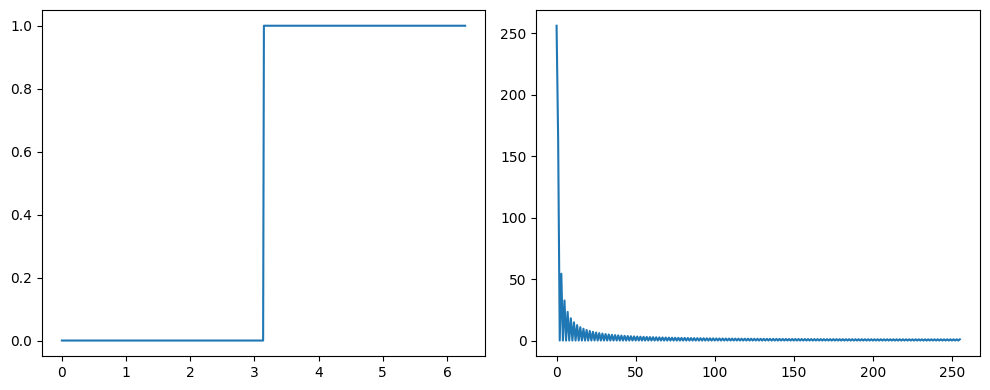

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()

ax[0].plot(tvals, fvals)
ax[1].plot(ffreq_plot[int(Npts/2):])

plt.tight_layout()

In [9]:
tvalsfine = np.linspace(0, 2.*np.pi, 2*Npts)
interp_step = [interp_freq(tval, ffreq) for tval in tvalsfine]

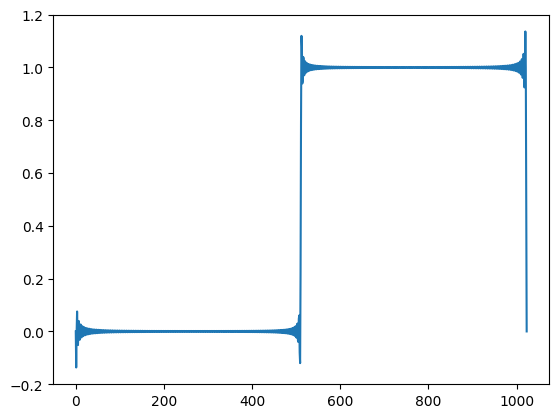

In [10]:
plt.plot(interp_step)

## The Fourier Transform

For $T$-periodic $f(t)$, if we let $T\rightarrow \infty$, we are lead to the trasnforms

$$
\hat{f}(\omega) = \int_{-\infty}^{\infty}e^{-i\omega t}f(t) dt, ~ f(t) = \frac{1}{2\pi}\int_{-\infty}^{\infty} e^{i\omega t}\hat{f}(\omega) d\omega
$$

With these tranforms, we can now study signals which do not necessarily repeat or have any particular structure at all.  To wit, we now look at the square pulse 
$$
I_{a}(t) = \frac{1}{a} I\left(\frac{t}{a}\right)
$$ 
where $a>0$ and where  

$$
I(t) = \left \{ 
\begin{array}{rl}
1 & -\frac{1}{2}\leq t \leq\frac{1}{2}\\
\\
0 & |t| > \frac{1}{2}
\end{array}
\right.
$$

We can readily see that 

$$
\hat{I}_{a}(\omega) = \frac{2}{\omega a}\sin\left(\frac{a\omega}{2}\right) = \text{sinc}\left(\frac{a\omega}{2}\right)
$$

So let's plot and see what happens.  

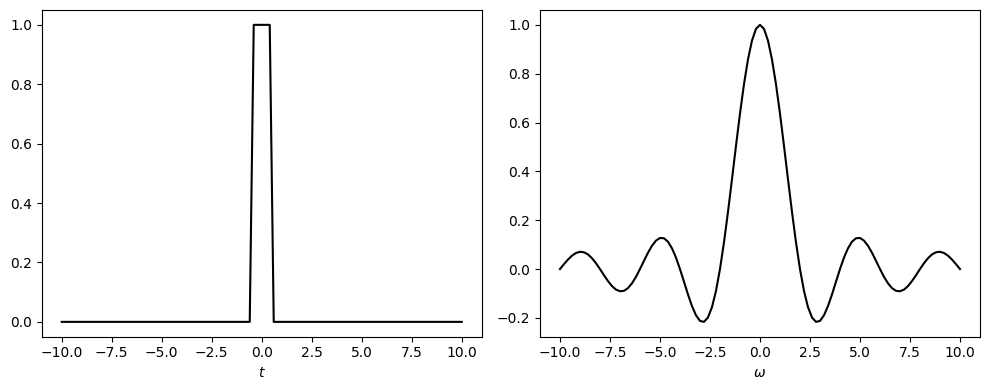

In [11]:
def sym_step(t):
    if np.abs(t) <= .5:
        return 1.
    else:
        return 0.

scale_step = lambda t, a: sym_step(t/a)/a

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()

Npts = 101
tvals = np.linspace(-10., 10., Npts)
ovals = np.linspace(-10., 10., Npts)

aval = 1.

scale_eval = np.array([ scale_step(tval, aval) for tval in tvals ])

ax[0].plot(tvals, scale_eval, c='k')
ax[0].set_xlabel(r"$t$")
ax[1].plot(ovals, np.sinc( ovals * aval/2. ), c='k')
ax[1].set_xlabel(r"$\omega$")

plt.tight_layout()

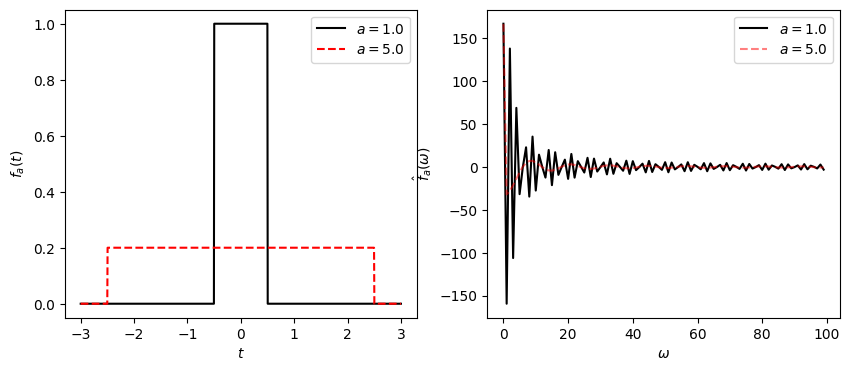

In [12]:
Npts = int(1e3)
tw = 3.
tvals = np.linspace(-tw, tw, Npts + 1)

aval1 = 1.
aval2 = 5.
stepvals1 = np.array([scale_step(tval, aval1) for tval in tvals])
stepvals2 = np.array([scale_step(tval, aval2) for tval in tvals])
fft1 = np.real(fft(stepvals1))
fft2 = np.real(fft(stepvals2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].plot(tvals, stepvals1, label=f"$a={aval1}$", color='k')
ax[0].plot(tvals, stepvals2, label=f"$a={aval2}$", color='r', ls='--')
ax[0].set_xlabel(r"$t$")
ax[0].set_ylabel(r"$f_{a}(t)$")
ax[0].legend()

ax[1].plot(fft1[:int(Npts/10)], label=f"$a={aval1}$", color='k')
ax[1].plot(fft2[:int(Npts/10)], label=f"$a={aval2}$", color='r', ls='--', alpha=.5)
ax[1].set_xlabel(r"$\omega$")
ax[1].set_ylabel(r"$\hat{f}_{a}(\omega)$")
ax[1].legend()

So what's the problem here?  Well first off, because we have a discontinuous signal, we get a very slowly decaying spectral representation of said signal, so we get no compression via frequency space.  We see this problem exacerbated by comparing the $a=1$ and $a=5$ cases.  But what we also lose is the fact that our signal only is even "on" for a relatively short amout of time.  So, given that via Fourier methods there is no way to get around the lack of compression in frequency space for sharp signals, can we at least come up with a method that still identifies when signals turn off, on, or change in significant ways and that gives us frequency characterizations which change in time?  